In [20]:

using Markdown
using InteractiveUtils
using Graphs, Random, GraphPlot, Plots, Colors, GraphRecipes
using ITensors, ITensorMPS, LinearAlgebra
using Cairo, Fontconfig

In [21]:

function adj_mat_lin(N::Int)
    A = zeros(N, N)
    for i in 1:N-1
        A[i, i+1] = 1.0
        A[i+1, i] = 1.0
    end
    return A
end

function adj_mat_ent(N::Int)
    A = ones(N, N)
    A -= Matrix{Float64}(I, N, N) # Set diagonal to zero (no self-coupling)
    return A
end

function adj_mat_ent_weighted(N::Int, σ)
    A = zeros(Float64, N, N)
    for i in 1:N, j in (i+1):N
        weight = 1 + σ * randn()
        A[i, j] = A[j, i] = weight
    end
    return A
end

function adj_mat_rand(N, P)
    return Graphs.adjacency_matrix(Graphs.erdos_renyi(N, P))
end



adj_mat_rand (generic function with 1 method)

[0.0 1.0 0.0 0.0 0.0; 1.0 0.0 1.0 0.0 0.0; 0.0 1.0 0.0 1.0 0.0; 0.0 0.0 1.0 0.0 1.0; 0.0 0.0 0.0 1.0 0.0]


5×5 Matrix{Float64}:
 0.0  1.0  0.0  0.0  0.0
 1.0  0.0  1.0  0.0  0.0
 0.0  1.0  0.0  1.0  0.0
 0.0  0.0  1.0  0.0  1.0
 0.0  0.0  0.0  1.0  0.0

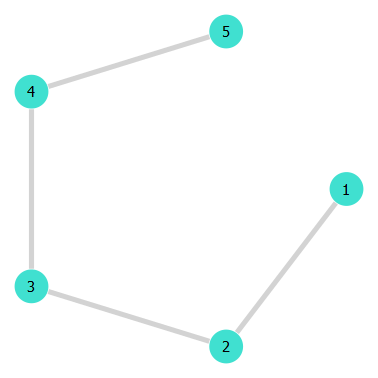

In [22]:
adjmat = adj_mat_lin(5)
println(adjmat)
display(adjmat)


G = Graphs.SimpleGraph(adjmat)
N = size(adjmat, 1)

node_labels = [string(i) for i in 1:N]

p = GraphPlot.gplot(
    G, 
    layout=circular_layout,
    nodelabel=node_labels,
    nodesize=0.3,
    nodelabelsize=3,
    edgelinewidth=2.0,
) 
display(p)


[0.0 1.0 1.0 1.0 1.0; 1.0 0.0 1.0 1.0 1.0; 1.0 1.0 0.0 1.0 1.0; 1.0 1.0 1.0 0.0 1.0; 1.0 1.0 1.0 1.0 0.0]


5×5 Matrix{Float64}:
 0.0  1.0  1.0  1.0  1.0
 1.0  0.0  1.0  1.0  1.0
 1.0  1.0  0.0  1.0  1.0
 1.0  1.0  1.0  0.0  1.0
 1.0  1.0  1.0  1.0  0.0

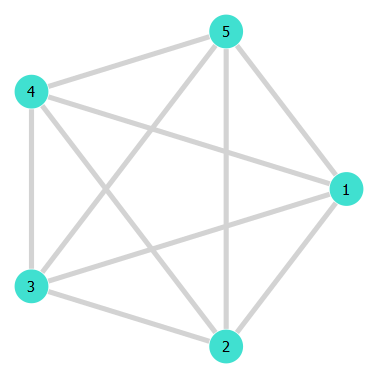

In [23]:
adjmat = adj_mat_ent(5)
println(adjmat)
display(adjmat)


G = Graphs.SimpleGraph(adjmat)
N = size(adjmat, 1)

node_labels = [string(i) for i in 1:N]

p = GraphPlot.gplot(
    G, 
    layout=circular_layout,
    nodelabel=node_labels,
    nodesize=0.3,
    nodelabelsize=3,
    edgelinewidth=2.0,
) 
display(p)

[0.0 1.008770683849967 1.1911422153713445 1.1873705327262494 0.9142824590174072; 1.008770683849967 0.0 0.8538322312534403 0.7198826948167703 1.3066187010485932; 1.1911422153713445 0.8538322312534403 0.0 0.9406856541968459 1.5429644916262064; 1.1873705327262494 0.7198826948167703 0.9406856541968459 0.0 0.9212675720504557; 0.9142824590174072 1.3066187010485932 1.5429644916262064 0.9212675720504557 0.0]


5×5 Matrix{Float64}:
 0.0       1.00877   1.19114   1.18737   0.914282
 1.00877   0.0       0.853832  0.719883  1.30662
 1.19114   0.853832  0.0       0.940686  1.54296
 1.18737   0.719883  0.940686  0.0       0.921268
 0.914282  1.30662   1.54296   0.921268  0.0

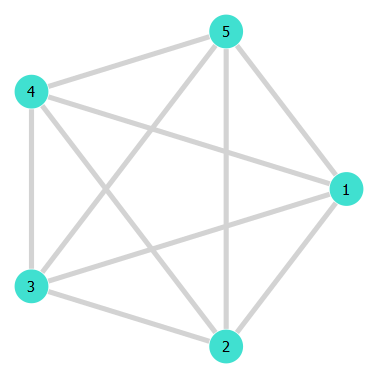

In [26]:
adjmat = adj_mat_ent_weighted(5, 0.2)
println(adjmat)
display(adjmat)


G = Graphs.SimpleGraph(adjmat)
N = size(adjmat, 1)

node_labels = [string(i) for i in 1:N]

p = GraphPlot.gplot(
    G, 
    layout=circular_layout,
    nodelabel=node_labels,
    nodesize=0.3,
    nodelabelsize=3,
    edgelinewidth=2.0,
) 
display(p)

sparse([2, 3, 4, 1, 5, 1, 5, 1, 2, 3], [1, 1, 1, 2, 2, 3, 3, 4, 5, 5], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 5, 5)


5×5 SparseArrays.SparseMatrixCSC{Int64, Int64} with 10 stored entries:
 ⋅  1  1  1  ⋅
 1  ⋅  ⋅  ⋅  1
 1  ⋅  ⋅  ⋅  1
 1  ⋅  ⋅  ⋅  ⋅
 ⋅  1  1  ⋅  ⋅

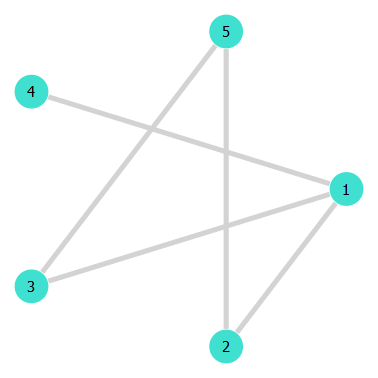

In [25]:
adjmat = adj_mat_rand(5, 0.4)
println(adjmat)
display(adjmat)


G = Graphs.SimpleGraph(adjmat)
N = size(adjmat, 1)

node_labels = [string(i) for i in 1:N]

p = GraphPlot.gplot(
    G, 
    layout=circular_layout,
    nodelabel=node_labels,
    nodesize=0.3,
    nodelabelsize=3,
    edgelinewidth=2.0,
) 
display(p)